# 02 - Baseline: TF-IDF + Logistic Regression
Owner: Engineer 1

Non-sequential baseline every other model needs to beat. Also picks the preprocessing strategy (A-D) the rest of the project uses.

Result: macro-F1 0.9747, accuracy 0.9958. Preprocessing barely mattered - A_minimal won, B/C/D tied with it.

## 1. Setup
Local or Colab. In Colab this clones the repo and installs requirements; you still need to upload the Zindi zip into `data/`.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Manzi453/Formative_2-Group_19.git"
BRANCH = "feature/baseline-tfidf"  # change to main once merged

if "google.colab" in sys.modules:
    if not Path("Formative_2-Group_19").exists():
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
    os.chdir("Formative_2-Group_19")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # running from notebooks/ locally -> move to the repo root so relative paths work
    if Path.cwd().name == "notebooks":
        os.chdir("..")

sys.path.insert(0, str(Path.cwd()))
print("Working directory:", Path.cwd())

Working directory: /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19


In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from src.utils import set_seed, SEED, RESULTS_DIR, MODELS_DIR
from src.data_loader import load_raw, make_split, ID_COL, TEXT_COL, LABEL_COL
from src.preprocessing import STRATEGIES
from src.eda import length_features
from src.evaluation import compute_metrics, per_class_report, confusion
from src.plotting import save_fig, plot_confusion_matrix
from src.experiments import log_experiment, EXPERIMENTS_CSV

set_seed()
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50, "display.width", 140)

METRICS = RESULTS_DIR / "metrics"
ERRORS = RESULTS_DIR / "errors"
PREDICTIONS = RESULTS_DIR / "predictions"
BASELINE_DIR = MODELS_DIR / "baseline"
for d in (METRICS, ERRORS, PREDICTIONS, BASELINE_DIR):
    d.mkdir(parents=True, exist_ok=True)

PREPROCESSING_LOG = METRICS / "preprocessing_experiments.csv"
PREP_COLUMNS = [
    "experiment_id", "strategy", "transformation", "rationale", "model",
    "validation_macro_f1", "validation_accuracy", "effect_on_performance",
]

print("seed =", SEED, "| pandas", pd.__version__, "| numpy", np.__version__)

seed = 42 | pandas 3.0.6 | numpy 2.5.3


## 2. Data and shared split
Same split as notebook 01, reproduced and checked against `results/metrics/split.csv`.

In [3]:
train, test, sample = load_raw()
train_df, val_df = make_split(train)

split_path = METRICS / "split.csv"
if split_path.exists():
    saved_split = pd.read_csv(split_path)
    reproduced = pd.concat([
        train_df[[ID_COL]].assign(split="train"),
        val_df[[ID_COL]].assign(split="val"),
    ]).reset_index(drop=True)
    merged = saved_split.merge(reproduced, on=ID_COL, suffixes=("_saved", "_reproduced"))
    assert len(merged) == len(saved_split) == len(reproduced), "split sizes disagree with results/metrics/split.csv"
    assert (merged["split_saved"] == merged["split_reproduced"]).all(), "make_split(train) no longer reproduces the saved split"
    print("Reproduced split matches results/metrics/split.csv exactly.")
else:
    print("results/metrics/split.csv not found - run notebook 01 first. Continuing with a freshly computed split.")

CLASS_ORDER = list(train_df[LABEL_COL].value_counts().index)
print(f"train={len(train_df):,}  validation={len(val_df):,}  classes={CLASS_ORDER}")

Reproduced split matches results/metrics/split.csv exactly.
train=31,719  validation=7,931  classes=['sexual_violence', 'Physical_violence', 'emotional_violence', 'economic_violence', 'Harmful_Traditional_practice']


## 3. Preprocessing experiments (A-D)
Runs each cleaning strategy from `src/preprocessing.py` through the same TF-IDF + LogReg setup and compares macro-F1.

In [4]:
TRANSFORMATIONS = {
    "A_minimal": "strip() only - case, punctuation, emojis kept",
    "B_no_url_mention": "URLs -> '<url>', @mentions -> '<user>'",
    "C_normalize_repeats": "collapse whitespace and 3+ repeated characters to 2",
    "D_hashtag_words": "'#word' -> 'word'",
}
RATIONALE = {
    "A_minimal": "Control condition: no cleaning beyond whitespace stripping.",
    "B_no_url_mention": "Tests whether normalising the (rare, per notebook 01) URLs/@mentions helps or just discards signal.",
    "C_normalize_repeats": "Tests whether normalising emphasis (e.g. 'sooo' -> 'soo') helps the sparse TF-IDF vocabulary.",
    "D_hashtag_words": "Tests whether hashtags (rare here per notebook 01) still help once treated as ordinary words.",
}


def run_preprocessing_experiment(strategy_name: str) -> dict:
    clean = STRATEGIES[strategy_name]
    X_train_text = train_df[TEXT_COL].map(clean)
    X_val_text = val_df[TEXT_COL].map(clean)

    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True)
    X_train = vec.fit_transform(X_train_text)
    X_val = vec.transform(X_val_text)

    clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
    clf.fit(X_train, train_df[LABEL_COL])
    preds = clf.predict(X_val)
    return compute_metrics(val_df[LABEL_COL], preds)


prep_rows = []
for strategy in STRATEGIES:
    metrics = run_preprocessing_experiment(strategy)
    prep_rows.append({
        "experiment_id": f"prep_{strategy}",
        "strategy": strategy,
        "transformation": TRANSFORMATIONS[strategy],
        "rationale": RATIONALE[strategy],
        "model": "tfidf_logreg",
        "validation_macro_f1": round(metrics["macro_f1"], 4),
        "validation_accuracy": round(metrics["validation_accuracy"], 4),
        "effect_on_performance": "NOT YET MEASURED",
    })

prep_results = pd.DataFrame(prep_rows).sort_values("validation_macro_f1", ascending=False).reset_index(drop=True)

baseline_f1 = prep_results.loc[prep_results["strategy"] == "A_minimal", "validation_macro_f1"].iloc[0]

def describe_effect(row):
    if row["strategy"] == "A_minimal":
        return "control condition"
    diff = row["validation_macro_f1"] - baseline_f1
    direction = "improves" if diff > 0 else "no improvement" if diff < 0 else "no change"
    return f"{diff:+.4f} macro-F1 vs A_minimal ({direction})"

prep_results["effect_on_performance"] = prep_results.apply(describe_effect, axis=1)
prep_results

,experiment_id,strategy,transformation,rationale,model,validation_macro_f1,validation_accuracy,effect_on_performance
0,prep_A_minimal,A_minimal,"strip() only - case, punctuation, emojis kept",Control condition: no cleaning beyond whitespa...,tfidf_logreg,0.9747,0.9958,control condition
1,prep_B_no_url_mention,B_no_url_mention,"URLs -> '<url>', @mentions -> '<user>'","Tests whether normalising the (rare, per noteb...",tfidf_logreg,0.9747,0.9958,+0.0000 macro-F1 vs A_minimal (no change)
2,prep_C_normalize_repeats,C_normalize_repeats,collapse whitespace and 3+ repeated characters...,Tests whether normalising emphasis (e.g. 'sooo...,tfidf_logreg,0.9747,0.9958,+0.0000 macro-F1 vs A_minimal (no change)
3,prep_D_hashtag_words,D_hashtag_words,'#word' -> 'word',Tests whether hashtags (rare here per notebook...,tfidf_logreg,0.9747,0.9958,+0.0000 macro-F1 vs A_minimal (no change)


In [5]:
write_header = not PREPROCESSING_LOG.exists() or PREPROCESSING_LOG.stat().st_size == 0
prep_results[PREP_COLUMNS].to_csv(PREPROCESSING_LOG, mode="a", header=write_header, index=False)

BEST_STRATEGY = prep_results.iloc[0]["strategy"]
spread = prep_results["validation_macro_f1"].max() - prep_results["validation_macro_f1"].min()
print(f"Best preprocessing strategy: {BEST_STRATEGY} (macro-F1={prep_results['validation_macro_f1'].max():.4f}). "
      f"Spread across the 4 strategies: {spread:.4f} macro-F1 points.")

Best preprocessing strategy: A_minimal (macro-F1=0.9747). Spread across the 4 strategies: 0.0000 macro-F1 points.


## 4. Final baseline model
Trains the final pipeline with the winning strategy from above.

In [6]:
FINAL_STRATEGY = BEST_STRATEGY
clean = STRATEGIES[FINAL_STRATEGY]

X_train_text = train_df[TEXT_COL].map(clean)
X_val_text = val_df[TEXT_COL].map(clean)
y_train, y_val = train_df[LABEL_COL], val_df[LABEL_COL]

baseline_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
])

start = time.time()
baseline_pipeline.fit(X_train_text, y_train)
train_time = time.time() - start

val_preds = baseline_pipeline.predict(X_val_text)
metrics = compute_metrics(y_val, val_preds)
print(f"preprocessing = {FINAL_STRATEGY} | train_time = {train_time:.1f}s | vocabulary = {len(baseline_pipeline.named_steps['tfidf'].vocabulary_):,} n-grams")
pd.Series(metrics)

preprocessing = A_minimal | train_time = 2.7s | vocabulary = 63,313 n-grams


validation_accuracy    0.995839
macro_precision        0.963246
macro_recall           0.988249
macro_f1               0.974747
weighted_f1            0.995899
dtype: float64

## 5. Per-class performance and confusion matrix

,precision,recall,f1-score,support
Harmful_Traditional_practice,1.000000,0.947368,0.972973,38.000000
Physical_violence,0.991653,0.998319,0.994975,1190.000000
economic_violence,0.934783,1.000000,0.966292,43.000000
emotional_violence,0.890411,1.000000,0.942029,130.000000
sexual_violence,0.999385,0.995559,0.997468,6530.000000
accuracy,0.995839,0.995839,0.995839,0.995839
macro avg,0.963246,0.988249,0.974747,7931.000000
weighted avg,0.996091,0.995839,0.995899,7931.000000


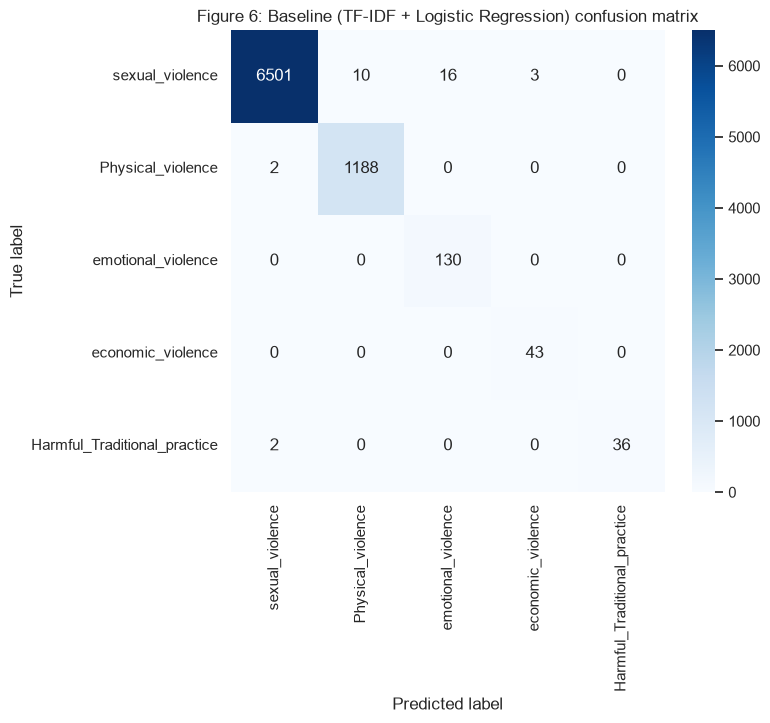

In [7]:
report = per_class_report(y_val, val_preds)
report.to_csv(METRICS / "baseline_per_class_report.csv")
display(report)

cm = confusion(y_val, val_preds, labels=CLASS_ORDER)
fig = plot_confusion_matrix(cm, CLASS_ORDER, "Figure 6: Baseline (TF-IDF + Logistic Regression) confusion matrix")
save_fig(fig, "fig06_baseline_confusion_matrix")
plt.show()

## 6. Most predictive tokens per class
Top n-grams per class by LogReg coefficient - for interpretation only, not used as rules.

In [8]:
vec = baseline_pipeline.named_steps["tfidf"]
clf = baseline_pipeline.named_steps["clf"]
feature_names = np.array(vec.get_feature_names_out())

top_rows = []
for i, cls in enumerate(clf.classes_):
    coefs = clf.coef_[i]
    top_idx = np.argsort(coefs)[::-1][:15]
    for rank, idx in enumerate(top_idx, 1):
        top_rows.append({"class": cls, "rank": rank, "token": feature_names[idx], "coefficient": round(float(coefs[idx]), 3)})

top_features = pd.DataFrame(top_rows)
top_features.to_csv(METRICS / "baseline_top_features.csv", index=False)
top_features.pivot(index="rank", columns="class", values="token")

class,Harmful_Traditional_practice,Physical_violence,economic_violence,emotional_violence,sexual_violence
rank,,,,,
1,forced,beats,fired,public,raped
2,marriage,husband,job,humiliated,he
3,child marriage,my husband,woman,insulted,raped me
4,fgm,beats me,because,in public,he raped
5,mutilation,my,was fired,in,was raped
6,genital mutilation,husband beats,fired from,insulted me,rape
7,undergo,he beats,job because,humiliated me,me
8,genital,wife,was,the public,raped and
9,female genital,beats the,my job,verbally,raped by


## 7. Error analysis
Misclassified IDs + labels only, no tweet text (tweets can contain graphic content).

In [9]:
val_lengths = length_features(val_df, TEXT_COL)
mask = val_preds != y_val.values
errors = val_df.loc[mask, [ID_COL, LABEL_COL]].rename(columns={LABEL_COL: "true_label"}).copy()
errors["predicted"] = val_preds[mask]
errors["tokens"] = val_lengths.loc[errors.index, "tokens"]
errors.to_csv(ERRORS / "baseline_errors.csv", index=False)

print(f"Misclassified: {len(errors)} / {len(val_df)} ({100 * len(errors) / len(val_df):.2f}%)")
errors.groupby(["true_label", "predicted"]).size().sort_values(ascending=False).head(10)

Misclassified: 33 / 7931 (0.42%)


true_label                    predicted         
sexual_violence               emotional_violence    16
                              Physical_violence     10
                              economic_violence      3
Harmful_Traditional_practice  sexual_violence        2
Physical_violence             sexual_violence        2
dtype: int64

## 8. Save the fitted pipeline and log the run

In [10]:
MODEL_PATH = BASELINE_DIR / "tfidf_logreg.pkl"
joblib.dump(baseline_pipeline, MODEL_PATH)

log_experiment(
    experiment_id="baseline_tfidf_logreg_v1",
    model="tfidf_logreg",
    preprocessing=FINAL_STRATEGY,
    tokenizer="tfidf_word_ngram_1_2_min_df_3",
    sequence_length="n/a (bag-of-ngrams)",
    embedding="n/a",
    learning_rate="n/a",
    batch_size="n/a",
    epochs="n/a",
    optimizer="lbfgs",
    dropout="n/a",
    train_time=f"{train_time:.1f}s",
    validation_accuracy=round(metrics["validation_accuracy"], 4),
    macro_precision=round(metrics["macro_precision"], 4),
    macro_recall=round(metrics["macro_recall"], 4),
    macro_f1=round(metrics["macro_f1"], 4),
    weighted_f1=round(metrics["weighted_f1"], 4),
    notes=f"TF-IDF(1-2 gram, min_df=3) + LogisticRegression(class_weight=balanced); preprocessing={FINAL_STRATEGY} chosen from experiments A-D.",
    next_action="Compare against LSTM/CNN/TCN/Transformer in notebook 07; this is the non-sequential baseline they must beat.",
)
print(f"Saved pipeline to {MODEL_PATH}")
print(f"Logged run to {EXPERIMENTS_CSV}")

val_predictions = val_df[[ID_COL]].assign(true_label=y_val.values, predicted_label=val_preds)
val_predictions.to_csv(PREDICTIONS / "baseline_val_predictions.csv", index=False)
print(f"Saved validation predictions to {PREDICTIONS / 'baseline_val_predictions.csv'}")

Saved pipeline to /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19/models/baseline/tfidf_logreg.pkl
Logged run to /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19/results/metrics/experiments.csv


Saved validation predictions to /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19/results/predictions/baseline_val_predictions.csv


## 9. Findings
Pulled straight from the tables above.

In [11]:
findings = {
    "preprocessing strategies compared": ", ".join(prep_results["strategy"]),
    "best preprocessing strategy": f"{BEST_STRATEGY} (macro-F1={prep_results['validation_macro_f1'].max():.4f})",
    "preprocessing macro-F1 spread": f"{spread:.4f}",
    "final baseline macro-F1": f"{metrics['macro_f1']:.4f}",
    "final baseline weighted-F1": f"{metrics['weighted_f1']:.4f}",
    "final baseline accuracy": f"{metrics['validation_accuracy']:.4f}",
    "majority-class accuracy (notebook 01)": "82.34%",
    "misclassified (val)": f"{len(errors)} / {len(val_df)} ({100 * len(errors) / len(val_df):.2f}%)",
    "vocabulary (1-2 gram, min_df=3)": f"{len(vec.vocabulary_):,}",
    "train time": f"{train_time:.1f}s",
}
pd.Series(findings, name="finding").to_frame()

,finding
preprocessing strategies compared,"A_minimal, B_no_url_mention, C_normalize_repea..."
best preprocessing strategy,A_minimal (macro-F1=0.9747)
preprocessing macro-F1 spread,0.0000
final baseline macro-F1,0.9747
final baseline weighted-F1,0.9959
final baseline accuracy,0.9958
majority-class accuracy (notebook 01),82.34%
misclassified (val),33 / 7931 (0.42%)
"vocabulary (1-2 gram, min_df=3)","63,313"
train time,2.7s
